  Data shape: (743, 7)
  Data shape: (672, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
Combined data shape: (8759, 7)
Columns after stripping: ['Date Time', 'Speed', 'Direction', 'Direction.1', 'Gust', 'X', 'R']
First few rows after processing:
            Date Time   WSPD   WDIR Direction.1   Gust  X  R  \
136  2017-01-06 17:00  21.19  357.0           N  25.66  0  0   
137  2017-01-06 18:00  20.41  346.0         NNW  26.05  0  0   
138  2017-01-06 19:00  20.99  347.0         NNW  26.82  0  0   
139  2017-01-06 20:00  17.49  340.0         NNW  22.35  0  0   
140  2017-01-06 21:00  17.11  354.0           N  21.58  0  0   

               datetime  
136 2017-01-06 17:00:00  
137 2017-01-06 18:00:00  
138 2017-01-06 19:00:00  
139 2017-01-06 20:00:00  
140 2017-01-06 21:00:00  


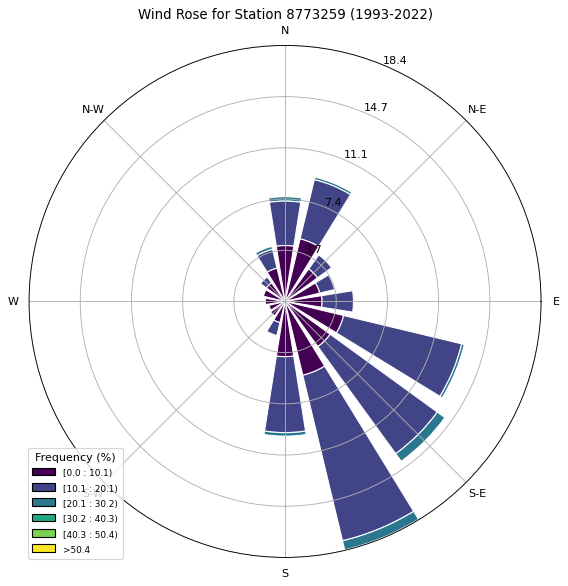

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
from windrose import WindroseAxes

# --- PARAMETERS ---
station_id = "8773259"   # Port Lavaca, TX station ID
start_date = pd.Timestamp("2017-01-01")
end_date   = pd.Timestamp("2017-12-31")
base_url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"

# --- DOWNLOAD DATA MONTH-BY-MONTH ---
data_frames = []
current_date = start_date
while current_date <= end_date:
    begin_date = current_date.strftime("%Y%m%d")
    end_of_month = (current_date + pd.offsets.MonthEnd(0)).strftime("%Y%m%d")
    
    url = (
        f"{base_url}?begin_date={begin_date}&end_date={end_of_month}"
        f"&station={station_id}&product=wind&time_zone=lst_ldt&interval=h"
        f"&units=english&application=DataAPI_Sample&format=csv"
    )
    print(f"Downloading data from {begin_date} to {end_of_month}...")
    
    try:
        response = requests.get(url)
        if response.status_code != 200:
            print(f"  Failed: HTTP {response.status_code}")
            current_date += pd.offsets.MonthBegin(1)
            continue
        if "No Data" in response.text:
            print("  No data for this period.")
            current_date += pd.offsets.MonthBegin(1)
            continue
        
        df_month = pd.read_csv(StringIO(response.text))
        if df_month.empty:
            print("  Received empty data.")
        else:
            data_frames.append(df_month)
            print(f"  Data shape: {df_month.shape}")
    except Exception as e:
        print(f"  Error: {e}")
    
    current_date += pd.offsets.MonthBegin(1)

if not data_frames:
    raise Exception("No data was downloaded! Please verify the station ID and date range on NOAA's website.")

# --- CONCATENATE ALL DATA ---
df_all = pd.concat(data_frames, ignore_index=True)
print(f"Combined data shape: {df_all.shape}")

# --- STRIP WHITESPACE FROM COLUMN NAMES ---
df_all.columns = df_all.columns.str.strip()
print("Columns after stripping:", df_all.columns.tolist())

# --- PROCESS DATE/TIME ---
if "Date Time" in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all["Date Time"])
elif "Date" in df_all.columns and "Time" in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all["Date"] + " " + df_all["Time"])
elif "date" in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all["date"])
else:
    raise Exception("No recognizable date/time columns found in the data.")

df_all.sort_values("datetime", inplace=True)

# --- RENAME WIND COLUMNS ---
# Based on your columns, we expect "Speed" and "Direction" to be the desired fields.
df_all.rename(columns={
    "Speed": "WSPD",
    "Direction": "WDIR"
}, inplace=True)

# Check that expected wind columns now exist:
expected = ["WSPD", "WDIR"]
for col in expected:
    if col not in df_all.columns:
        raise Exception(f"Expected wind column '{col}' not found. Available columns: {df_all.columns.tolist()}")

# --- DROP ROWS WITH MISSING WIND DATA ---
df_all = df_all.dropna(subset=["WSPD", "WDIR"])
print("First few rows after processing:")
print(df_all.head())

# --- CREATE WIND ROSE PLOT ---
ax = WindroseAxes.from_ax()
ax.bar(df_all["WDIR"], df_all["WSPD"], normed=True, opening=0.8, edgecolor="white")
ax.set_legend(title="Frequency (%)")
plt.title(f"Wind Rose for Station {station_id} (1993-2022)")
plt.show()


  Data shape: (743, 7)
  Data shape: (672, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
  Data shape: (720, 7)
  Data shape: (744, 7)
Combined data shape: (8759, 7)
Columns in concatenated data: ['Date Time', ' Speed', ' Direction', ' Direction.1', ' Gust', ' X', ' R ']
Columns after stripping: ['Date Time', 'Speed', 'Direction', 'Direction.1', 'Gust', 'X', 'R']
First few rows after processing:
            Date Time   WSPD   WDIR Direction.1   Gust  X  R  \
136  2017-01-06 17:00  21.19  357.0           N  25.66  0  0   
137  2017-01-06 18:00  20.41  346.0         NNW  26.05  0  0   
138  2017-01-06 19:00  20.99  347.0         NNW  26.82  0  0   
139  2017-01-06 20:00  17.49  340.0         NNW  22.35  0  0   
140  2017-01-06 21:00  17.11  354.0           N  21.58  0  0   

               datetime  
136 2017-01-06 17:00:00  
137 2017-01-06 18:00:00

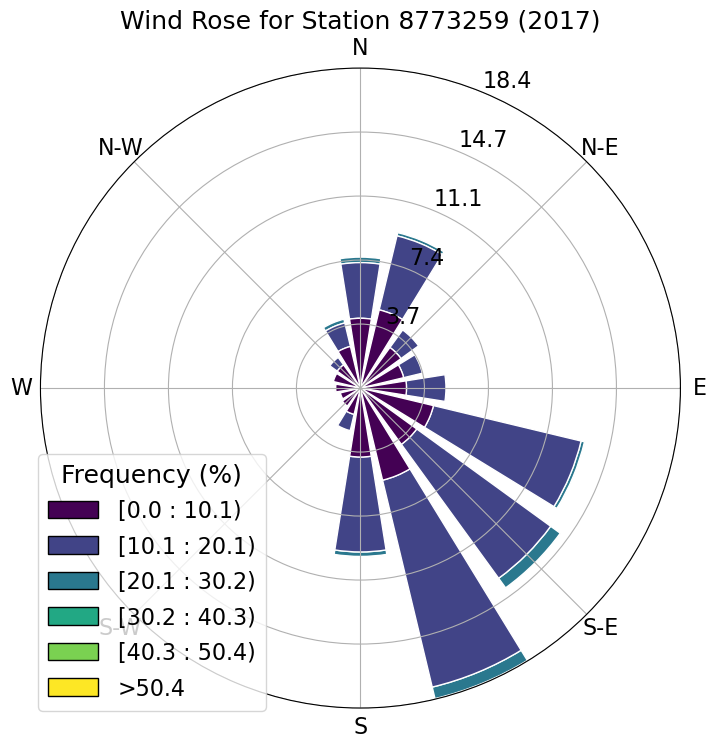

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
from windrose import WindroseAxes

# --- PARAMETERS ---
station_id = "8773259"   # Port Lavaca, TX station ID
start_date = pd.Timestamp("2017-01-01")
end_date   = pd.Timestamp("2017-12-31")
base_url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"

# --- DOWNLOAD DATA MONTH-BY-MONTH ---
data_frames = []
current_date = start_date
while current_date <= end_date:
    begin_date = current_date.strftime("%Y%m%d")
    end_of_month = (current_date + pd.offsets.MonthEnd(0)).strftime("%Y%m%d")
    
    url = (
        f"{base_url}?begin_date={begin_date}&end_date={end_of_month}"
        f"&station={station_id}&product=wind&time_zone=lst_ldt&interval=h"
        f"&units=english&application=DataAPI_Sample&format=csv"
    )
    print(f"Downloading data from {begin_date} to {end_of_month}...")
    
    try:
        response = requests.get(url)
        if response.status_code != 200:
            print(f"  Failed: HTTP {response.status_code}")
            current_date += pd.offsets.MonthBegin(1)
            continue
        if "No Data" in response.text:
            print("  No data for this period.")
            current_date += pd.offsets.MonthBegin(1)
            continue
        
        df_month = pd.read_csv(StringIO(response.text))
        if df_month.empty:
            print("  Received empty data.")
        else:
            data_frames.append(df_month)
            print(f"  Data shape: {df_month.shape}")
    except Exception as e:
        print(f"  Error: {e}")
    
    current_date += pd.offsets.MonthBegin(1)

if not data_frames:
    raise Exception("No data was downloaded! Please verify the station ID and date range on NOAA's website.")

# --- CONCATENATE ALL DATA ---
df_all = pd.concat(data_frames, ignore_index=True)
print(f"Combined data shape: {df_all.shape}")
print("Columns in concatenated data:", df_all.columns.tolist())

# --- STRIP WHITESPACE FROM COLUMN NAMES ---
df_all.columns = df_all.columns.str.strip()
print("Columns after stripping:", df_all.columns.tolist())

# --- PROCESS DATE/TIME ---
if "Date Time" in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all["Date Time"])
elif "Date" in df_all.columns and "Time" in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all["Date"] + " " + df_all["Time"])
elif "date" in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all["date"])
else:
    raise Exception("No recognizable date/time columns found in the data.")

df_all.sort_values("datetime", inplace=True)

# --- RENAME WIND COLUMNS ---
# Based on the printed columns, rename "Speed" and "Direction" to "WSPD" and "WDIR"
df_all.rename(columns={
    "Speed": "WSPD",
    "Direction": "WDIR"
}, inplace=True)

# --- DROP ROWS WITH MISSING WIND DATA ---
df_all = df_all.dropna(subset=["WSPD", "WDIR"])
print("First few rows after processing:")
print(df_all.head())

# --- SET FIGURE FONT SIZES (Journal Standard) ---
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 18
})

# --- CREATE WIND ROSE PLOT ---
fig = plt.figure(figsize=(10, 8))
ax = WindroseAxes.from_ax(fig=fig)

# Plot the windrose
ax.bar(df_all["WDIR"], df_all["WSPD"], normed=True, opening=0.8, edgecolor="white")

# Set legend using the windrose API
ax.set_legend(title="Frequency (%)")

# Increase legend font sizes by accessing the underlying legend object
legend = ax.legend_
if legend is not None:
    # Set bin label font sizes
    for text in legend.get_texts():
        text.set_fontsize(16)
    # Set legend title font size
    legend.set_title("Frequency (%)")
    plt.setp(legend.get_title(), fontsize=18)

plt.title(f"Wind Rose for Station {station_id} (2017)", fontsize=18)
plt.show()
